# STAGE 1

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

experiments = {
    "Baseline": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/A0_baseline/metrics_eval.csv",
    "TCN": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/A1_tcn/A1_TCNneck/metrics_eval.csv",
    "TempShift": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/A2_tshift/A2_TempShift/metrics_eval.csv",
    "TCN+TempShift": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/A3_tcn_tshift/A3_TCNneck_TempShift/metrics_eval.csv",
    "TCN+RNY008": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/A5_tcn_rny008/A5_TCNneck_RNY008/metrics_eval.csv",
    "TCN+TempShift+RNY008": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/A4_tcn_tshift_rny008/A4_TCNneck_TempShift_RNY008/metrics_eval.csv",
}

In [55]:
data = []
for name, path in experiments.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        
        # Extract the specific row where class == 'AP10' (or fallback to 'mAP10')
        row = df.loc[df['class'].isin(['AP10', 'mAP10', 'map10'])]
        
        if not row.empty:
            # Multiply by 100 to display as a percentage (e.g., 54.2%)
            val = row['average_precision'].values[0] * 100 
            data.append({"Experiment": name, "mAP10": val})
        else:
            print(f"⚠️ Warning: 'AP10' row not found in {path}")
    else:
        print(f"❌ Error: File not found -> {path}")

df_plot = pd.DataFrame(data)

/tmp/ipykernel_1623662/3449643891.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Experiment", y="mAP10", data=df_plot, palette=colors, edgecolor='black')


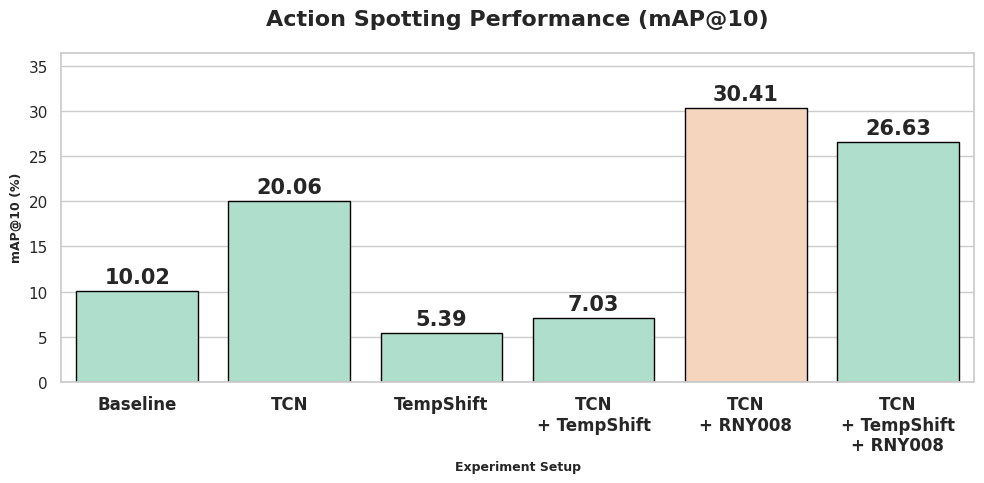

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your defined palette
PASTEL_COLORS = ["#A8E6CF", "#FFD3B6", "#FFAAA5", "#D5AAFF", "#CFCFCF"]
LINE_COLORS = {"cyan": "#5BC0DE", "tomato": "#FF7F6E", "green": "#82B366"}
SHORT_DASHES = (0, (2, 2))

if not df_plot.empty:
    # 1. Format the experiment names to span two lines by splitting at the "+" sign
    df_plot["Experiment"] = df_plot["Experiment"].apply(lambda x: x.replace('+', '\n+ '))

    # Slightly reduced figure width since we don't need horizontal space for angled text
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")

    # Find the maximum value to highlight it
    max_val = df_plot["mAP10"].max()
    
    # 2. Use the new PASTEL_COLORS palette
    # PASTEL_COLORS[1] (#FFD3B6 - pastel orange) for the best, PASTEL_COLORS[0] (#A8E6CF - pastel mint) for the rest
    colors = [PASTEL_COLORS[1] if val == max_val else PASTEL_COLORS[0] for val in df_plot["mAP10"]]

    # Create the bar plot
    ax = sns.barplot(x="Experiment", y="mAP10", data=df_plot, palette=colors, edgecolor='black')

    # Add the exact numbers on top of each bar
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), # Offset by 10 pixels upwards
                    textcoords='offset points',
                    fontweight='bold', 
                    fontsize=15)

    # Styling the text and axes
    plt.title("Action Spotting Performance (mAP@10)", fontsize=16, fontweight='bold', pad=20)
    plt.ylabel("mAP@10 (%)", fontsize=9, fontweight='bold')
    plt.xlabel("Experiment Setup", fontsize=9, fontweight='bold')
    
    # 3. Keep labels horizontal and centered now that they are split into multiple lines
    plt.xticks(rotation=0, ha="center", fontsize=12, fontweight='bold')
    
    # Expand Y axis slightly so the text labels don't get cut off at the top
    plt.ylim(0, max_val * 1.2) 

    # Show the plot
    plt.tight_layout()
    plt.show()
else:
    print("No data was loaded. Please check your file paths.")

# STAGE 2: TCN NECKS

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

experiments = {
    "TCN+RNY008": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/A5_tcn_rny008/A5_TCNneck_RNY008/metrics_eval.csv",
    "TCN_NoDropout": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/B1_TCN8_no_dropout/B1_TCN8_no_dropout/metrics_eval.csv",
    "TCN_LocalOnly": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/B3_TCN8_local_only/B3_TCN8_local_only/metrics_eval.csv",
    "TCN_Shallower": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/B2_TCN8_shallower/B2_TCN8_shallower/metrics_eval.csv",
    "TCN_Deeper": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/B4_TCN8_deeeper/B4_TCN8_deeeper/metrics_eval.csv"
}

In [58]:
data = []
for name, path in experiments.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        
        # Extract the specific row where class == 'AP10' (or fallback to 'mAP10')
        row = df.loc[df['class'].isin(['AP10', 'mAP10', 'map10'])]
        
        if not row.empty:
            # Multiply by 100 to display as a percentage (e.g., 54.2%)
            val = row['average_precision'].values[0] * 100 
            data.append({"Experiment": name, "mAP10": val})
        else:
            print(f"⚠️ Warning: 'AP10' row not found in {path}")
    else:
        print(f"❌ Error: File not found -> {path}")

df_plot = pd.DataFrame(data)

/tmp/ipykernel_1623662/3449643891.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Experiment", y="mAP10", data=df_plot, palette=colors, edgecolor='black')


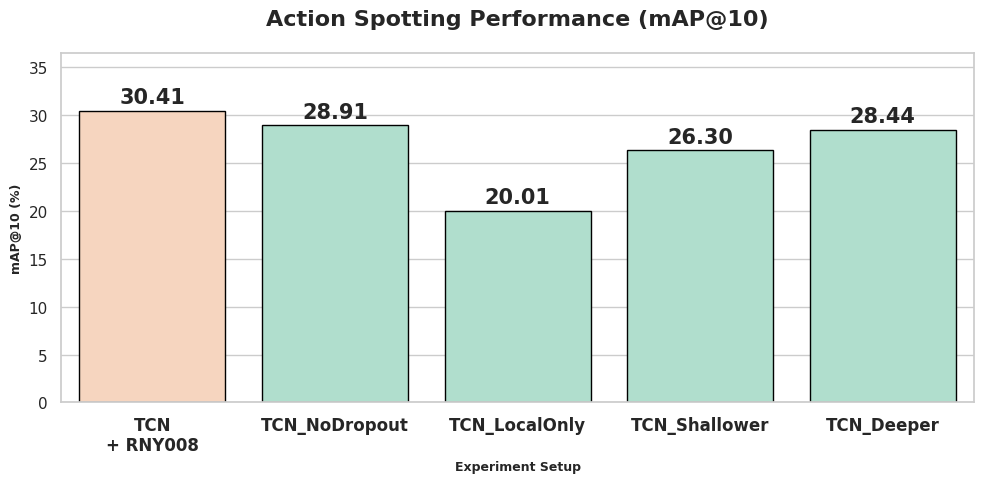

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your defined palette
PASTEL_COLORS = ["#A8E6CF", "#FFD3B6", "#FFAAA5", "#D5AAFF", "#CFCFCF"]
LINE_COLORS = {"cyan": "#5BC0DE", "tomato": "#FF7F6E", "green": "#82B366"}
SHORT_DASHES = (0, (2, 2))

if not df_plot.empty:
    # 1. Format the experiment names to span two lines by splitting at the "+" sign
    df_plot["Experiment"] = df_plot["Experiment"].apply(lambda x: x.replace('+', '\n+ '))

    # Slightly reduced figure width since we don't need horizontal space for angled text
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")

    # Find the maximum value to highlight it
    max_val = df_plot["mAP10"].max()
    
    # 2. Use the new PASTEL_COLORS palette
    # PASTEL_COLORS[1] (#FFD3B6 - pastel orange) for the best, PASTEL_COLORS[0] (#A8E6CF - pastel mint) for the rest
    colors = [PASTEL_COLORS[1] if val == max_val else PASTEL_COLORS[0] for val in df_plot["mAP10"]]

    # Create the bar plot
    ax = sns.barplot(x="Experiment", y="mAP10", data=df_plot, palette=colors, edgecolor='black')

    # Add the exact numbers on top of each bar
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), # Offset by 10 pixels upwards
                    textcoords='offset points',
                    fontweight='bold', 
                    fontsize=15)

    # Styling the text and axes
    plt.title("Action Spotting Performance (mAP@10)", fontsize=16, fontweight='bold', pad=20)
    plt.ylabel("mAP@10 (%)", fontsize=9, fontweight='bold')
    plt.xlabel("Experiment Setup", fontsize=9, fontweight='bold')
    
    # 3. Keep labels horizontal and centered now that they are split into multiple lines
    plt.xticks(rotation=0, ha="center", fontsize=12, fontweight='bold')
    
    # Expand Y axis slightly so the text labels don't get cut off at the top
    plt.ylim(0, max_val * 1.2) 

    # Show the plot
    plt.tight_layout()
    plt.show()
else:
    print("No data was loaded. Please check your file paths.")

# STAGE 4: ACTIONNESS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

experiments = {
    "TCN+RNY008": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/A5_tcn_rny008/A5_TCNneck_RNY008/metrics_eval.csv",
    "Balanced weighting": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/D3_actionness_lw05_alp05/D3_actionness_lw05_alp05/metrics_eval.csv",
    "Inference-focused": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/D1_actionness_lw05_alp1/D1_actionness_lw05_alp1/metrics_eval.csv",
    "Full weighting": "/ghome/group05/datasets/WEEK6/SN-BAS-2025_savedata/D2_actionness_lw1_alp1/D2_actionness_lw1_alp1/metrics_eval.csv",
}

In [72]:
data = []
for name, path in experiments.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        
        # Extract the specific row where class == 'AP10' (or fallback to 'mAP10')
        row = df.loc[df['class'].isin(['AP10', 'mAP10', 'map10'])]
        
        if not row.empty:
            # Multiply by 100 to display as a percentage (e.g., 54.2%)
            val = row['average_precision'].values[0] * 100 
            data.append({"Experiment": name, "mAP10": val})
        else:
            print(f"⚠️ Warning: 'AP10' row not found in {path}")
    else:
        print(f"❌ Error: File not found -> {path}")

df_plot = pd.DataFrame(data)

/tmp/ipykernel_1623662/3449643891.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Experiment", y="mAP10", data=df_plot, palette=colors, edgecolor='black')


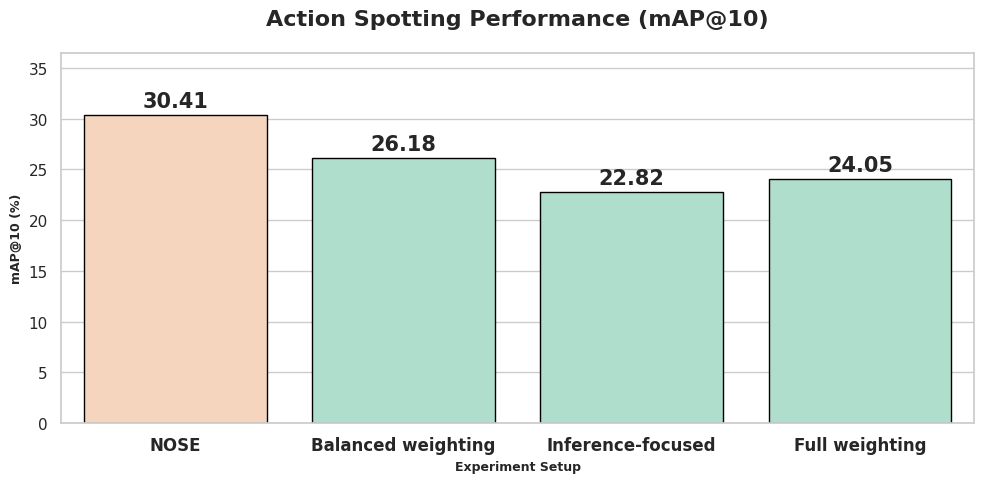

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your defined palette
PASTEL_COLORS = ["#A8E6CF", "#FFD3B6", "#FFAAA5", "#D5AAFF", "#CFCFCF"]
LINE_COLORS = {"cyan": "#5BC0DE", "tomato": "#FF7F6E", "green": "#82B366"}
SHORT_DASHES = (0, (2, 2))

if not df_plot.empty:
    # 1. Format the experiment names to span two lines by splitting at the "+" sign
    df_plot["Experiment"] = df_plot["Experiment"].apply(lambda x: x.replace('+', '\n+ '))

    # Slightly reduced figure width since we don't need horizontal space for angled text
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")

    # Find the maximum value to highlight it
    max_val = df_plot["mAP10"].max()
    
    # 2. Use the new PASTEL_COLORS palette
    # PASTEL_COLORS[1] (#FFD3B6 - pastel orange) for the best, PASTEL_COLORS[0] (#A8E6CF - pastel mint) for the rest
    colors = [PASTEL_COLORS[1] if val == max_val else PASTEL_COLORS[0] for val in df_plot["mAP10"]]

    # Create the bar plot
    ax = sns.barplot(x="Experiment", y="mAP10", data=df_plot, palette=colors, edgecolor='black')

    # Add the exact numbers on top of each bar
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), # Offset by 10 pixels upwards
                    textcoords='offset points',
                    fontweight='bold', 
                    fontsize=15)

    # Styling the text and axes
    plt.title("Action Spotting Performance (mAP@10)", fontsize=16, fontweight='bold', pad=20)
    plt.ylabel("mAP@10 (%)", fontsize=9, fontweight='bold')
    plt.xlabel("Experiment Setup", fontsize=9, fontweight='bold')
    
    # 3. Keep labels horizontal and centered now that they are split into multiple lines
    plt.xticks(rotation=0, ha="center", fontsize=12, fontweight='bold')
    
    # Expand Y axis slightly so the text labels don't get cut off at the top
    plt.ylim(0, max_val * 1.2) 

    # Show the plot
    plt.tight_layout()
    plt.show()
else:
    print("No data was loaded. Please check your file paths.")